# Feature Engineering và Selection
# 1. Xử lý đặc trưng số
## 1.1. Chuẩn hóa
- Tại sao cần chuẩn hóa: các thuật toán dựa trên việc tính khoảng cách như KNN, SVM, K-means hoặc gradient descent như linear regression, logistic regression nhạy cảm với thang đo của đặc trưng
  
**Min-Max scaling**
  $$x' = \frac{x-x_{min}}{x_{max}-x_{min}}$$
- Đưa dữ liệu về $[0, 1]$
- Nhạy với outlier

**Standardization (Z-score)**
  $$x' = \frac{x-\mu}{\sigma}$$
  
- Đưa về phân phối có $\mu=1, \sigma = 1$.
- Không giới hạn range cụ thể. Đây là lựa chọn mặc định cho phần lớn thuật toán
- Ít nhạy cảm với outlier hơn Min-Max scaling

**Scaling to unit length**
Một lựa chọn khác nữa cũng được sử dụng rộng rãi là chuẩn hóa các thành phần của mỗi vector dữ liệu sao cho toàn bộ vector có độ lớn (Euclid, tức norm 2) bằng 1. Việc này có thể được thực hiện bằng:
 $$x'=\frac{x}{||x||^2_2}$$

## 1.2. Biến đổi phi tuyến

### Tại sao cần biến đổi phi tuyến

- Giúp mô hình tuyến tính như Linear/Logistic Regression học được các mối quan hệ phức tạp trong thực tế.
- Xử lý ngoại lai và chuẩn hóa phân phối: Dữ liệu thực tế thường bị lệch và chứa các giá trị cực đoan, biến đổi phi tuyến giúp dữ liệu về gần dạng phân phối chuẩn, giúp mô hình hội tụ nhanh hơn.
- Có thể phát hiện các tương tác chéo giữa các đặc trưng, thay vì chỉ dùng $x_1, x_2$ có thể dùng cả $x_1 \times x_2$.

### Các dạng thường dùng

**Biến đổi Logarit (Cụ thể là Log1p: $\log(x+1)$)**

- Bản chất: Sử dụng hàm logarit để nén các giá trị lớn và kéo giãn các giá trị nhỏ. Cộng thêm $1$ để tránh lỗi toán học khi biến số bằng $0$.
- Trường hợp sử dụng: Các dữ liệu bị lệch phải (right-skewed) nặng nề như: Giá nhà, mức thu nhập, hoặc đếm tần suất.

> **Lưu ý:** 
> - Chỉ áp dụng được cho tập dữ liệu có giá trị $x \ge 0$.
> - Ít khi sử dụng $\log(x + c)$ vì nếu dùng $c \neq 1$ thì các giá trị $x = 0$ sẽ được biến đổi về khác $0$, làm cho ma trận từ thưa thớt trở nên dày đặc hơn, gây tốn RAM và làm tăng khối lượng tính toán.
> - Chỉ dùng phép biến đổi $\log(x + c)$ khi tập dữ liệu của bạn có chứa số âm. Hàm logarit không thể xử lý số âm hoặc số $0$ (vì $\log(\le 0)$ là vô nghĩa).

**Đặc trưng Đa thức (Polynomial Features)**

- Bản chất: Nâng lũy thừa các biến số hiện có (ví dụ: $x^2, x^3$) hoặc nhân chéo các biến với nhau (ví dụ: $x_1 x_2$).
- Trường hợp sử dụng: Thường dùng trong hồi quy tuyến tính để nắm bắt các xu hướng phức tạp giữa các đặc trưng.

> **Lưu ý:** Dễ gây ra hiện tượng bùng nổ số chiều (Curse of Dimensionality) làm tràn bộ nhớ và quá khớp (Overfitting) nếu bậc đa thức được dùng quá cao.

**Rời rạc hóa (Binning / Discretization)**

- Bản chất: Cắt một biến số thực liên tục thành các khoảng (bin) rời rạc. Ví dụ: Chuyển biến "Độ tuổi" (1-100) thành các nhóm "Trẻ em", "Thanh niên", "Trung niên".
- Trường hợp sử dụng: Khi biến mục tiêu thay đổi đột ngột theo từng giai đoạn (dạng bậc thang) thay vì theo một đường cong trơn tru.

> **Lưu ý:** Triệt tiêu hoàn toàn sự ảnh hưởng của giá trị ngoại lai (Outliers), nhưng phải đánh đổi bằng việc mất đi sự chi tiết của dữ liệu gốc.

## 1.3. Xử lý giá trị khuyết (Missing Data Imputation)

### Tại sao cần xử lý
Đa số các thuật toán Machine Learning (ngoại trừ một số mô hình dạng cây như XGBoost, LightGBM) không thể thực hiện tính toán toán học trên các giá trị rỗng (NaN/Null) và sẽ báo lỗi. Xử lý đúng cách giúp giữ lại tối đa lượng thông tin của tập dữ liệu mà không làm sai lệch phân phối gốc.

### Các phương pháp thường dùng

**Xóa bỏ dữ liệu (Deletion)**
- Bản chất: Xóa các dòng chứa giá trị khuyết hoặc xóa toàn bộ cột đặc trưng đó.
- Trường hợp sử dụng: Chỉ xóa dòng khi tỷ lệ thiếu rất nhỏ (< 5%). Xóa cột khi tỷ lệ thiếu quá lớn (> 50-60%) và biến đó không mang lại nhiều giá trị nghiệp vụ.
> **Lưu ý:** Phương pháp này nguy hiểm vì có thể gây mất mát thông tin quan trọng hoặc làm sụt giảm kích thước tập huấn luyện.

**Điền bằng Đại lượng thống kê (Statistical Imputation)**
- Bản chất: Điền giá trị khuyết bằng số Trung bình (Mean), Trung vị (Median), hoặc Yếu vị (Mode - Giá trị xuất hiện nhiều nhất) của chính cột đó.
- Trường hợp sử dụng: 
  - *Mean*: Dành cho dữ liệu số có phân phối chuẩn, không có Outliers.
  - *Median*: Dành cho dữ liệu số bị lệch (skewed) hoặc có nhiều Outliers.
  - *Mode*: Dành cho dữ liệu phân loại (Categorical).
> **Lưu ý:** Nhanh và dễ triển khai, nhưng làm giảm phương sai (variance) của dữ liệu và phá vỡ mối tương quan với các biến khác.

**Điền bằng Hằng số (Constant Imputation)**
- Bản chất: Thay thế NaN bằng một giá trị cố định, ví dụ như `-999`, `-1` (cho dữ liệu số) hoặc `"Unknown"`, `"Missing"` (cho dữ liệu chữ).
- Trường hợp sử dụng: Khi bản thân "sự thiếu sót" cũng mang một hàm ý nào đó (Ví dụ: Khách hàng không điền cột "Thu nhập" có thể ngầm hiểu là họ không có việc làm).

**Điền bằng Thuật toán Học máy (Model-based Imputation)**
- Bản chất: Dùng các cột dữ liệu còn lại để dự đoán giá trị của ô bị khuyết (biến việc điền khuyết thành một bài toán Machine Learning con). Hai thuật toán phổ biến nhất là `KNNImputer` và `IterativeImputer` (MICE).
  * `KNNImputer`: Dựa trên các đặc trưng không bị thiếu để đo khoảng cách và tìm ra $K$ điểm dữ liệu gần nhất (giống nhất). Với biến phân loại (chữ) thì điền giá trị xuất hiện nhiều nhất (`mode`), với biến liên tục (số) thì điền trung bình hoặc trung vị (`mean`/`median`), có thể kết hợp đánh trọng số theo khoảng cách.
  * `IterativeImputer`: Đầu tiên điền tạm thời giá trị `mode`, `median` hoặc `mean` vào toàn bộ các ô bị thiếu. Sau đó, lần lượt duyệt qua từng đặc trưng: dùng các dòng có sẵn giá trị thật làm tập train để huấn luyện mô hình, và dùng mô hình đó dự đoán đắp lại vào các dòng bị khuyết. Quá trình xoay vòng này lặp đi lặp lại cho đến khi các con số hội tụ (không biến động nữa).
- Trường hợp sử dụng: Khi cần độ chính xác cao và tập dữ liệu có sự tương quan mạnh giữa các đặc trưng với nhau.
> **Lưu ý:** Độ chính xác rất cao, giữ được hoàn hảo mối quan hệ phân phối gốc giữa các biến, nhưng bù lại sẽ tiêu tốn nhiều tài nguyên máy tính và thời gian chạy.

# 2. Categorical Encoding
## 2.1. **One-Hot-Encoding**
- Tạo các cột tương ứng với từng giá trị trong đặc trưng
- Với mỗi mẫu, cột tương ứng với giá trị của đặc trưng sẽ được đánh số 1, các cột còn lại là 0
  
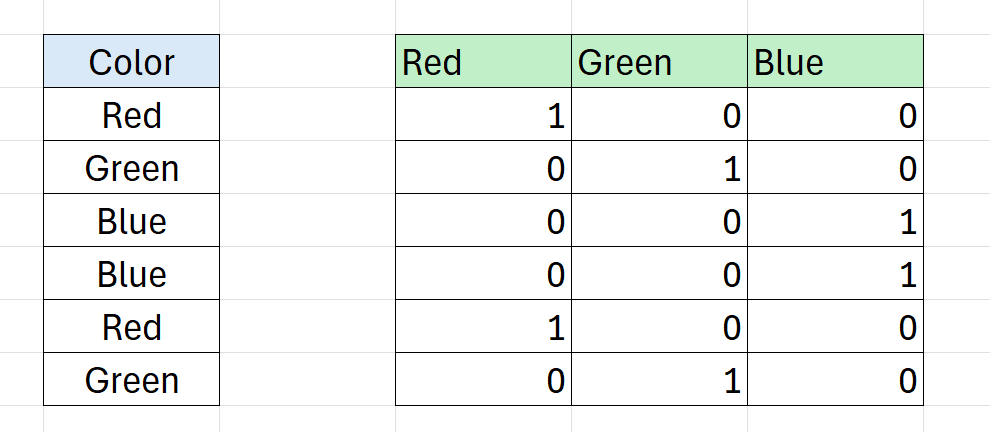

## 2.2. **Label-Encoding**
- Các giá trị được ánh xạ tương ứng với các số nguyên từ 0
  
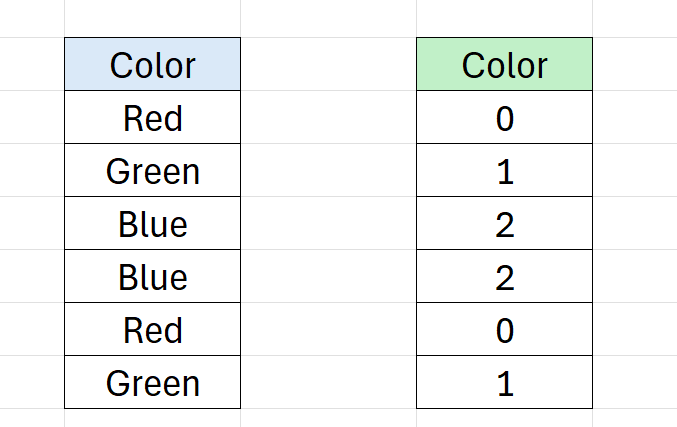

## 2.3. **Target-Encoding**

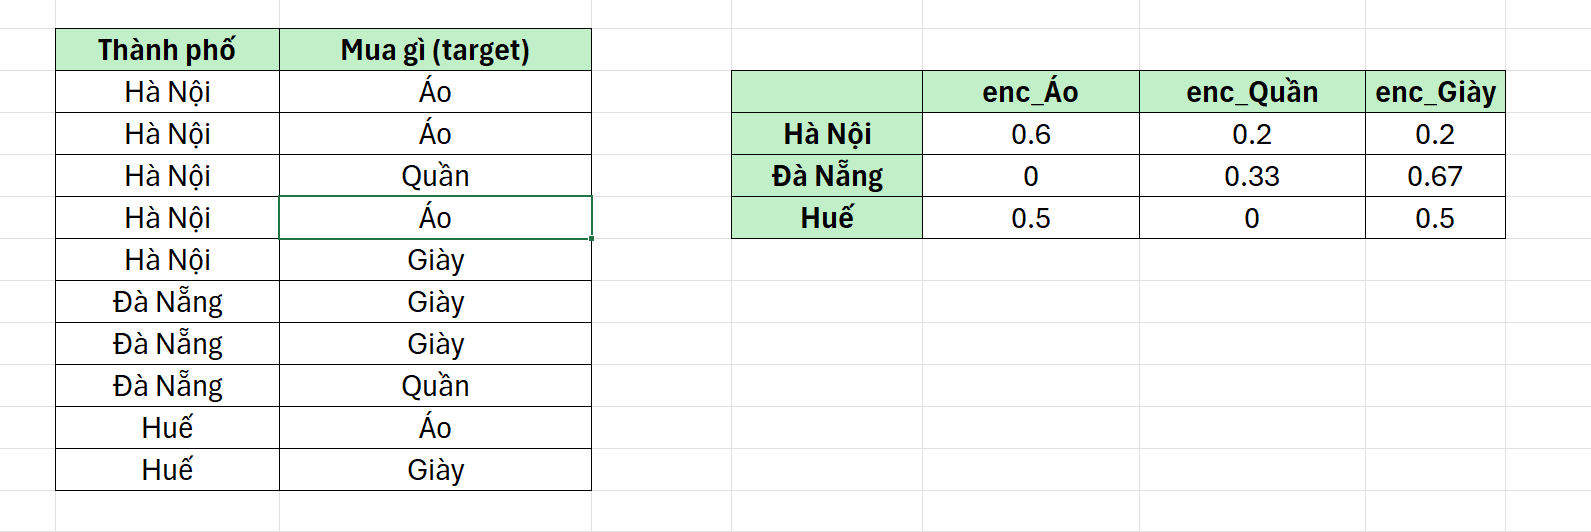
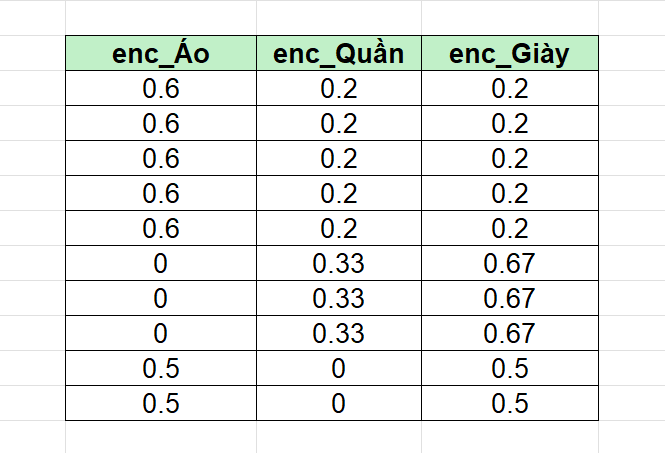

**Hà Nội** có 5 dòng (Áo xuất hiện 3 lần, Quần 1 lần, Giày 1 lần):

* $P(\text{Áo}\vert{}\text{HN}) = 3/5 = 0.6$
* $P(\text{Quần}\vert{}\text{HN}) = 1/5 = 0.2$
* $P(\text{Giày}\vert{}\text{HN}) = 1/5 = 0.2$

**Đà Nẵng** có 3 dòng (Giày xuất hiện 2 lần, Quần 1 lần, Áo 0 lần):

* $P(\text{Áo}\vert{}\text{ĐN}) = 0$
* $P(\text{Quần}\vert{}\text{ĐN}) = 1/3 \approx 0.33$
* $P(\text{Giày}\vert{}\text{ĐN}) = 2/3 \approx 0.67$

**Huế** có 2 dòng (Áo xuất hiện 1 lần, Giày 1 lần, Quần 0 lần):

* $P(\text{Áo}\vert{}\text{Huế}) = 1/2 = 0.5$
* $P(\text{Quần}\vert{}\text{Huế}) = 0$
* $P(\text{Giày}\vert{}\text{Huế}) = 1/2 = 0.5$

Đây là naive-target-encoding, dễ bị rò rỉ dữ liệu

### k-Fold-Target-Encoding
- Chia tập dữ liệu thành $k$ fold, mã hóa 1 fold bằng target trong $k-1$ fold còn lại
  
  **Ví dụ:**
  
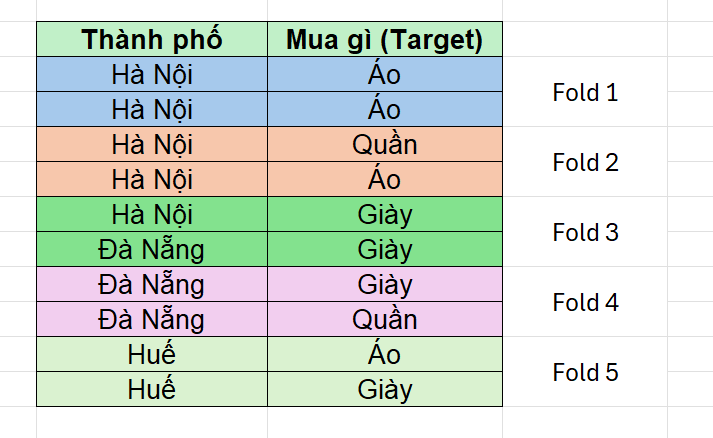

- Tính cho Fold-1

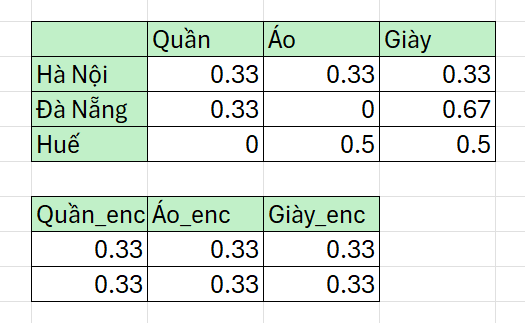

- Tương tự cho các Fold khác ta được bảng

  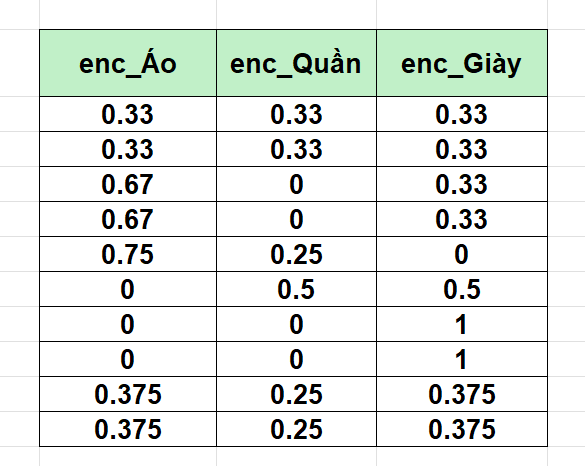

# 3. Đặc trưng văn bản

> *Máy tính không thể hiểu được văn bản như con người, do đó ta phải biến đổi văn bản về dạng các vector số học.*

---

## Count Vectorizer (Bag-of-Words)

Biểu diễn văn bản thành vector bằng cách đếm tần suất từ trong từ điển (vocabulary), hoàn toàn bỏ qua thứ tự từ.

**Quy trình thực hiện:**

1. **Xây dựng từ điển:** Gom tất cả các từ duy nhất xuất hiện trong toàn bộ các văn bản.
2. **Đếm tần suất:** Đếm số lần xuất hiện của từng từ trong mỗi văn bản.
3. **Mã hóa:** Chuyển văn bản thành một vector tần suất tương ứng với từ điển.

**Ví dụ minh họa:**

* **Văn bản 1 (D1):** "con mèo đuổi con chuột"
* **Văn bản 2 (D2):** "con chuột chạy"

Từ điển được xây dựng gồm $5$ từ: `['con', 'mèo', 'đuổi', 'chuột', 'chạy']`.

| Văn bản | con | mèo | đuổi | chuột | chạy | Vector biến đổi |
| --- | --- | --- | --- | --- | --- | --- |
| **D1** | 2 | 1 | 1 | 1 | 0 | **`[2, 1, 1, 1, 0]`** |
| **D2** | 1 | 0 | 0 | 1 | 1 | **`[1, 0, 0, 1, 1]`** |

**Nhược điểm:**

* Mất hoàn toàn thông tin về ngữ cảnh và thứ tự các từ.
* Không phân biệt được từ khóa quan trọng với các từ phổ biến nhưng ít ý nghĩa (stop words như: *là, và, với...*).

---

## TF-IDF (Term Frequency - Inverse Document Frequency)

**Nguyên lý cốt lõi:** Một từ là quan trọng đối với một văn bản nếu nó xuất hiện rất nhiều lần trong văn bản đó, nhưng lại rất hiếm xuất hiện ở các văn bản khác.

Giá trị của một từ $t$ trong văn bản $d$ thuộc tập dữ liệu $D$ được tính bằng tích của hai thành phần:

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

### 1. TF (Term Frequency)

Đo lường mức độ phổ biến của từ $t$ bên trong *riêng văn bản $d$*.

$$\text{TF}(t, d) = \frac{\text{Số lần từ } t \text{ xuất hiện trong } d}{\text{Tổng số từ trong } d}$$

### 2. IDF (Inverse Document Frequency)

Đo lường mức độ hiếm và độc đáo của từ $t$ trên *toàn bộ tập dữ liệu $D$* (Đại diện cho lượng thông tin từ đó mang lại).

$$\text{IDF}(t, D) = \log\left(\frac{\text{Tổng số văn bản } (N)}{\text{Số văn bản có chứa từ } t}\right)$$

---

**Ví dụ tính toán TF-IDF:**

Tập dữ liệu gồm $3$ văn bản:

* **D1:** "tôi ăn cơm"
* **D2:** "tôi ăn phở"
* **D3:** "tôi ăn bún"

Từ điển của toàn bộ hệ thống gồm $5$ từ: `["tôi", "ăn", "cơm", "phở", "bún"]`.

**Bước 1: Tính TF cho văn bản D1**

* $\text{TF}(\text{"tôi"}) = 1/3$
* $\text{TF}(\text{"ăn"}) = 1/3$
* $\text{TF}(\text{"cơm"}) = 1/3$
* $\text{TF}(\text{"phở"}) = 0$
* $\text{TF}(\text{"bún"}) = 0$

**Bước 2: Tính IDF cho các từ trong D1**

* $\text{IDF}(\text{"tôi"}) = \log(3/3) = 0$
* $\text{IDF}(\text{"ăn"}) = \log(3/3) = 0$
* $\text{IDF}(\text{"cơm"}) = \log(3/1) \approx 1.58$

**Kết quả:**
Nhân giá trị TF với IDF, ta có vector TF-IDF của văn bản **D1** như sau:

$$[0,\ 0,\ 1.58,\ 0,\ 0]$$

> **Kết luận:** Bằng toán học, TF-IDF đã triệt tiêu các từ vô nghĩa ("tôi", "ăn") và phát hiện ra từ **"cơm"** chính là từ khóa mang lại nhiều thông tin nhất để định danh cho văn bản D1.

# Rò rỉ dữ liệu
### Định nghĩa*
Data leakage xảy ra khi thông tin từ ngoài phạm vi hợp lệ (thường là từ tập test, từ tương lai, hoặc trực tiếp từ target) vô tình lọt vào quá trình training, khiến model có độ chính xác ảo cao trên validation/test nhưng sụp đổ khi triển khai thực tế (vì thông tin đó không tồn tại tại thời điểm dự đoán thật).
### Hai loại chính
- Target leakage: feature chứa thông tin sinh ra sau hoặc do target, không có sẵn tại thời điểm dự đoán.
  - Ví dụ kinh điển: dự đoán khả năng mắc viêm phổi dùng feature "đã từng nhập ICU" — feature này chỉ có giá trị true sau khi bệnh đã nặng, tức là hệ quả chứ không phải nguyên nhân/tiền đề.
- Train-test contamination: thông tin từ test set lọt vào quá trình fit các bước tiền xử lý trên train.
  - Ví dụ:
      * Fit StandardScaler/impute mean trên toàn bộ dataset trước khi train_test_split — thống kê train đã "nhìn thấy" test.
      * Target encoding tính trên toàn bộ train rồi dùng lại để transform chính các dòng đó

### Cách chống rò rỉ
**Chống rò rỉ mục tiêu:**

- Phân tích theo dòng thời gian: Tại thời điểm hệ thống vận hành thực tế và cần đưa ra dự đoán, đặc trưng này đã có dữ liệu chưa?
- Truy tìm các tương quan cao bất thường (Suspicious Correlation): Thực hiện phân tích tương quan giữa các đặc trưng và biến mục tiêu. Nếu phát hiện một biến có độ tương quan cao một cách đáng ngờ (ví dụ: > 0.90), đó thường là dấu hiệu của rò rỉ mục tiêu.
  
**Chống nhiễm chéo dữ liệu:**

- Chia tập train, test trước khi thực hiện làm sạch dữ liệu, chuẩn hóa
- Quy tắc fit/transform:
    - Trên tập Train: Sử dụng fit_transform(). Mô hình sẽ tính ra Mean, Phương sai, hoặc Từ điển dựa trên tập Train và biến đổi tập Train.
    - Trên tập Test: CHỈ SỬ DỤNG transform(). Tuyệt đối không gọi hàm fit trên tập Test. Mô hình sẽ dùng các tham số đã học từ tập Train để biến đổi tập Test một cách thụ động.



# Tổng kết

## Sơ đồ tư duy tổng quan

```mermaid
graph LR
    %% Root
    Root[Feature Engineering]

    %% Level 1
    Num[1. Đặc trưng số <br/> Numeric]
    Cat[2. Đặc trưng phân loại <br/> Categorical]
    Txt[3. Đặc trưng văn bản <br/> Text]
    Leak[Rò rỉ dữ liệu <br/> Data Leakage]

    Root --> Num
    Root --> Cat
    Root --> Txt
    Root --> Leak

    %% Level 2 - Numeric
    Num_Norm[Chuẩn hóa]
    Num_Nonlin[Biến đổi phi tuyến]
    Num_Impute[Xử lý giá trị khuyết]

    Num --> Num_Norm
    Num --> Num_Nonlin
    Num --> Num_Impute

    %% Level 3 - Numeric
    Num_Norm_Details["Min-Max <br/> Standardization (Z-score) <br/> Unit length"]
    Num_Nonlin_Details["Log1p <br/> Polynomial <br/> Binning"]
    Num_Impute_Details["Deletion <br/> Statistical (Mean/Median/Mode) <br/> Constant <br/> Model-based (KNNImputer, IterativeImputer/MICE)"]

    Num_Norm --> Num_Norm_Details
    Num_Nonlin --> Num_Nonlin_Details
    Num_Impute --> Num_Impute_Details

    %% Level 2 - Categorical
    Cat_OHE[One-Hot Encoding]
    Cat_LE[Label Encoding]
    Cat_TE[Target Encoding <br/> Naive vs k-Fold]

    Cat --> Cat_OHE
    Cat --> Cat_LE
    Cat --> Cat_TE

    %% Level 2 - Text
    Txt_CV[Count Vectorizer <br/> Bag-of-Words]
    Txt_TFIDF[TF-IDF]

    Txt --> Txt_CV
    Txt --> Txt_TFIDF

    %% Level 2 - Data Leakage
    Leak_Target[Target leakage]
    Leak_TrainTest[Train-test contamination]
    Leak_Prevent[Cách phòng chống]

    Leak --> Leak_Target
    Leak --> Leak_TrainTest
    Leak --> Leak_Prevent

    %% Level 3 - Data Leakage
    Leak_Prevent_Details["Time-aware split <br/> Fit trên Train / Transform trên Test"]
    Leak_Prevent --> Leak_Prevent_Details

    %% Styling
    classDef rootNode fill:#2d3436,stroke:#000,stroke-width:2px,color:#fff,font-weight:bold;
    classDef levelOne fill:#0984e3,stroke:#000,stroke-width:2px,color:#fff;
    classDef levelTwo fill:#74b9ff,stroke:#000,stroke-width:1px,color:#000;
    classDef levelThree fill:#dfe6e9,stroke:#000,stroke-width:1px,color:#000;

    class Root rootNode;
    class Num,Cat,Txt,Leak levelOne;
    class Num_Norm,Num_Nonlin,Num_Impute,Cat_OHE,Cat_LE,Cat_TE,Txt_CV,Txt_TFIDF,Leak_Target,Leak_TrainTest,Leak_Prevent levelTwo;
    class Num_Norm_Details,Num_Nonlin_Details,Num_Impute_Details,Leak_Prevent_Details levelThree;
```
## Bảng so sánh nhanh

| Kỹ thuật | Khi nào dùng | Nhược điểm chính |
|---|---|---|
| Min-Max Scaling | Cần range cố định [0,1] | Nhạy outlier |
| Standardization | Mặc định cho phần lớn thuật toán | Không bound cụ thể |
| Log1p | Dữ liệu lệch phải, $x \ge 0$ | Không xử lý được số âm |
| Polynomial Features | Bắt tương tác phi tuyến | Bùng nổ số chiều, dễ overfit |
| Binning | Target đổi bậc thang theo khoảng | Mất thông tin liên tục |
| Mean/Median/Mode Imputation | Thiếu ít, cần nhanh | Giảm phương sai, phá tương quan |
| Model-based Imputation | Cần độ chính xác cao | Tốn chi phí tính toán |
| One-Hot Encoding | Categorical không thứ tự, ít giá trị | Bùng nổ chiều nếu nhiều category |
| Label Encoding | Categorical có thứ tự, hoặc dùng cho tree-based | Tạo quan hệ thứ tự giả nếu dùng sai model |
| Target Encoding | Categorical nhiều giá trị (high-cardinality) | Dễ rò rỉ dữ liệu nếu làm naive |
| Count Vectorizer | Baseline đơn giản cho văn bản | Mất ngữ cảnh, nhạy stop words |
| TF-IDF | Cần phân biệt từ khóa quan trọng | Vẫn là bag-of-words, mất thứ tự từ |

## Nguyên tắc cốt lõi cần nhớ

1. **Luôn fit trên train, transform trên test** — áp dụng cho scaler, imputer, encoder, vectorizer.
2. **Chia train/test trước khi làm bất kỳ bước tiền xử lý nào.**
3. Với target encoding, luôn ưu tiên k-fold thay vì naive để giảm rò rỉ.
4. Khi nghi ngờ leakage: kiểm tra tương quan bất thường (> 0.9) và tính hợp lý theo trục thời gian của đặc trưng.
